##Importing libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

##Loading Dataset

In [ ]:
# Load the Iris dataset
iris_df = pd.read_csv('/content/Iris.csv')

# Display the first 5 rows of the DataFrame
display(iris_df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


##Exploratory Data Analysis(EDA)

In [ ]:
# Display the shape of the DataFrame
print(f"Shape of the DataFrame: {iris_df.shape}")

# Display information about the DataFrame (data types, non-null counts)
print("\nDataFrame Info:")
iris_df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(iris_df.describe())

Shape of the DataFrame: (150, 6)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Descriptive Statistics:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


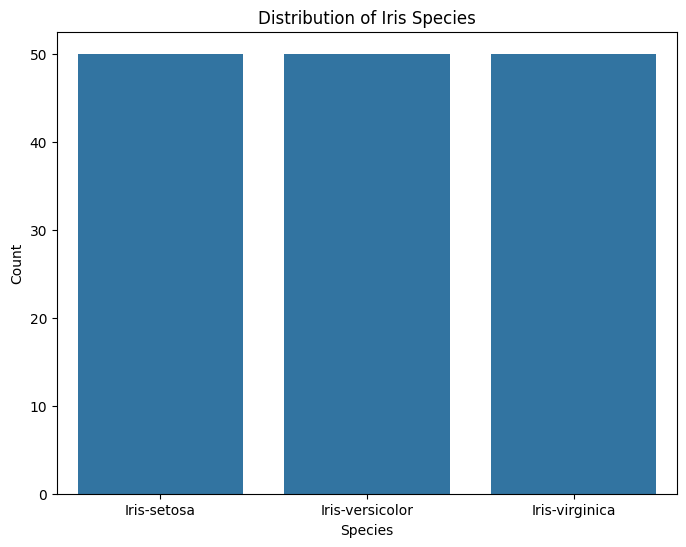

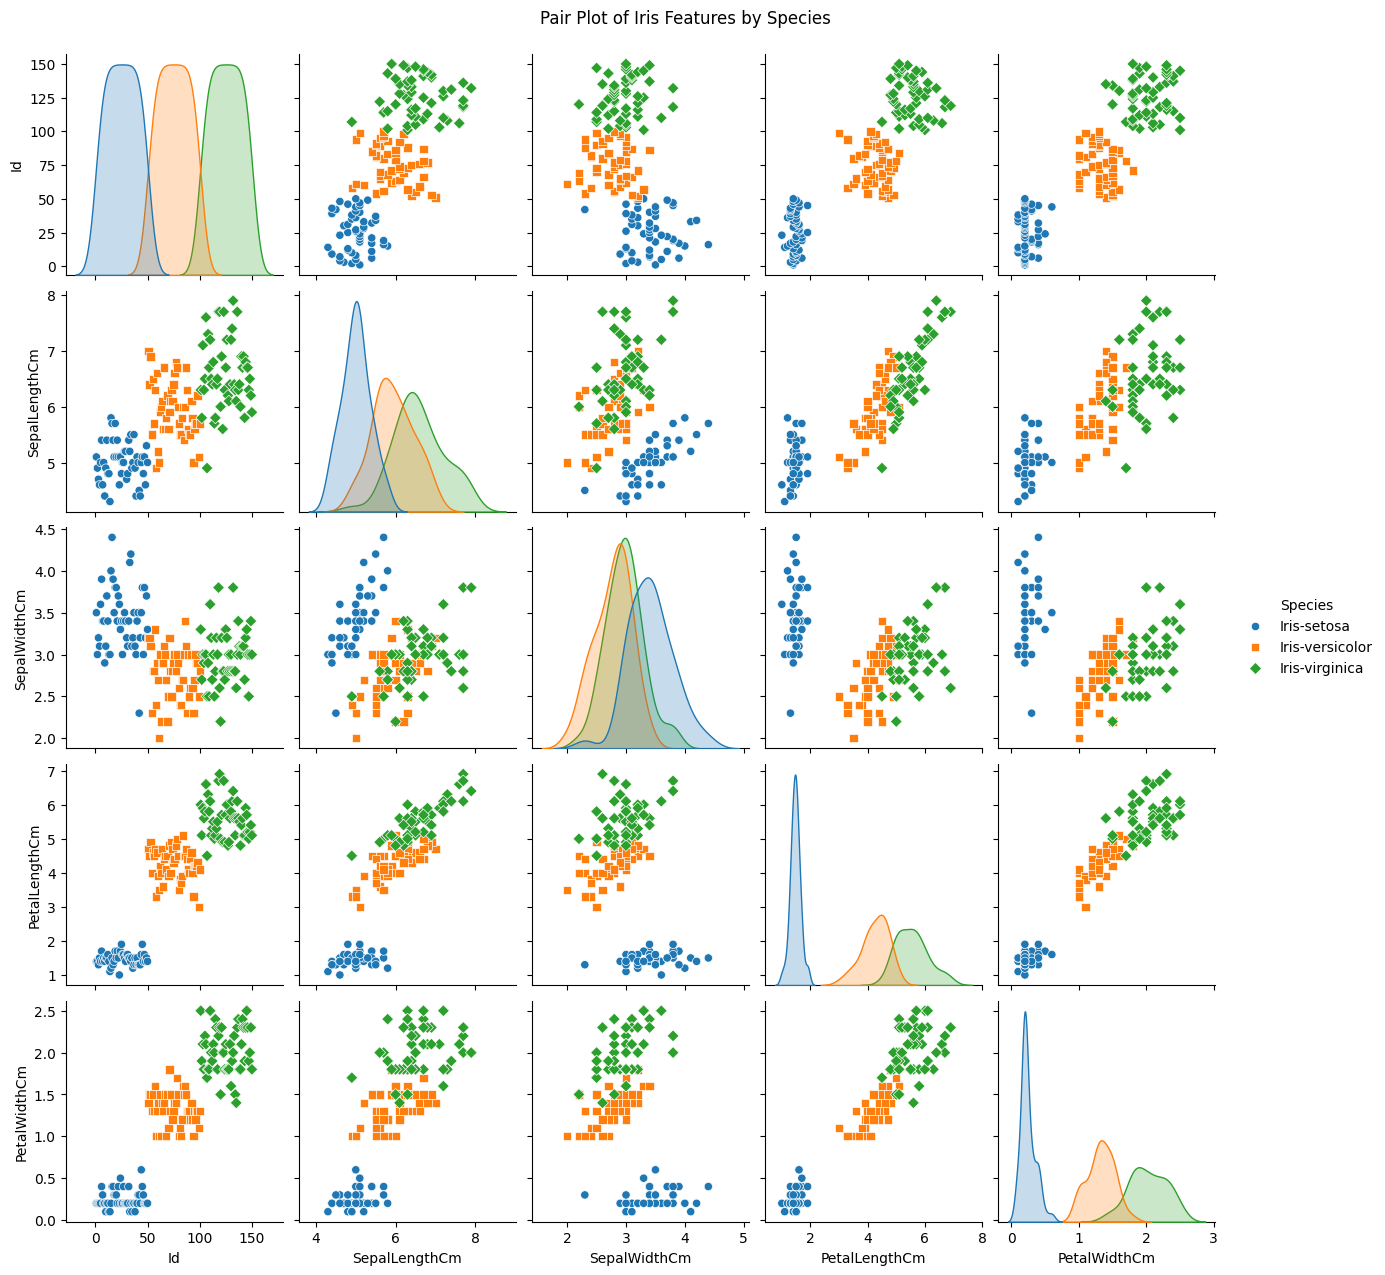

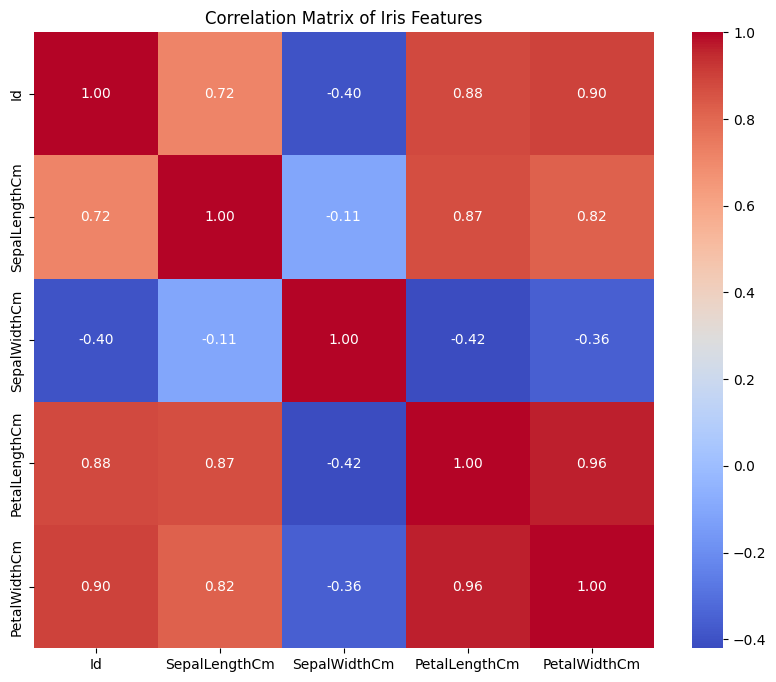

In [ ]:
# 1. Visualize the distribution of the target variable (Species)
plt.figure(figsize=(8, 6))
sns.countplot(x='Species', data=iris_df)
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# 2. Visualize relationships between features using a pair plot
sns.pairplot(iris_df, hue='Species', markers=['o', 's', 'D'])
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Adjust suptitle position
plt.show()

# 3. Calculate and visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(iris_df.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Iris Features')
plt.show()

##Data Cleaning

In [ ]:
# Drop the 'Id' column as it's not relevant for prediction
iris_df = iris_df.drop('Id', axis=1)

# Check for duplicate rows
duplicate_rows = iris_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# If there are duplicate rows, drop them
if duplicate_rows > 0:
    iris_df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")

# Display the first few rows and the new shape of the DataFrame after cleaning
print("\nDataFrame after cleaning:")
display(iris_df.head())
print(f"New shape of the DataFrame: {iris_df.shape}")

Number of duplicate rows: 3
Duplicate rows removed.

DataFrame after cleaning:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


New shape of the DataFrame: (147, 5)


In [ ]:
# Separate features (X) and target (y)
X = iris_df.drop('Species', axis=1)
y = iris_df['Species']

# Encode the target variable 'Species' into numerical labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Original Species labels:", y.unique())
print("Encoded Species labels:", np.unique(y_encoded))
print("Mapping:")
for i, species in enumerate(le.classes_):
    print(f"{species}: {i}")

# Display the first few rows of features (X) and encoded target (y_encoded)
print("\nFeatures (X) head:")
display(X.head())
print("\nEncoded Target (y_encoded) head:")
print(y_encoded[:5])

Original Species labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded Species labels: [0 1 2]
Mapping:
Iris-setosa: 0
Iris-versicolor: 1
Iris-virginica: 2

Features (X) head:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Encoded Target (y_encoded) head:
[0 0 0 0 0]


##Split Train and Test Data

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (117, 4)
Shape of X_test: (30, 4)
Shape of y_train: (117,)
Shape of y_test: (30,)


##Feature Scaling

In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled (first 5 rows):\n", X_train_scaled[:5])
print("\nX_test_scaled (first 5 rows):\n", X_test_scaled[:5])

X_train_scaled (first 5 rows):
 [[ 0.59486878  0.05831127  0.94250316  0.76726863]
 [-1.60687754  0.28572521 -1.38920785 -1.36694663]
 [-0.38368514 -0.62393057  0.60127716  1.03404553]
 [-0.8729621   0.96796705 -1.33233685 -1.36694663]
 [-1.11760058  1.195381   -1.38920785 -1.36694663]]

X_test_scaled (first 5 rows):
 [[ 0.22791106 -0.16910268  0.60127716  0.76726863]
 [-0.50600438 -1.7610003   0.08943815  0.10032636]
 [ 0.96182651  0.05831127  0.99937416  1.56759935]
 [-0.99528134  1.65020889 -1.33233685 -1.23355818]
 [-1.23991982 -1.30617241  0.37379316  0.63388017]]


##Train the Model

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(cm)


--- Training Logistic Regression ---
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]

--- Training Decision Tree ---
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[11  0  0]
 [ 

##Make Predictions

In [ ]:
# Select the Logistic Regression model for prediction (or any other model from 'models')
model_to_use = models['Logistic Regression']

# Make predictions on the scaled test data
y_pred_encoded = model_to_use.predict(X_test_scaled)

# Reverse the Label Encoding to get original species names
y_pred_species = le.inverse_transform(y_pred_encoded)
y_test_species = le.inverse_transform(y_test)

# Display some predictions
print("\n--- Sample Predictions ---")
num_samples_to_show = 10

for i in range(num_samples_to_show):
    print(f"Sample {i+1}:")
    print(f"  Features: {X_test.iloc[i].values}") # Original features before scaling
    print(f"  Predicted Species: {y_pred_species[i]}")
    print(f"  Actual Species: {y_test_species[i]}")
    print("------------------------")


--- Sample Predictions ---
Sample 1:
  Features: [6.1 3.  4.9 1.8]
  Predicted Species: Iris-virginica
  Actual Species: Iris-virginica
------------------------
Sample 2:
  Features: [5.5 2.3 4.  1.3]
  Predicted Species: Iris-versicolor
  Actual Species: Iris-versicolor
------------------------
Sample 3:
  Features: [6.7 3.1 5.6 2.4]
  Predicted Species: Iris-virginica
  Actual Species: Iris-virginica
------------------------
Sample 4:
  Features: [5.1 3.8 1.5 0.3]
  Predicted Species: Iris-setosa
  Actual Species: Iris-setosa
------------------------
Sample 5:
  Features: [4.9 2.5 4.5 1.7]
  Predicted Species: Iris-versicolor
  Actual Species: Iris-virginica
------------------------
Sample 6:
  Features: [4.8 3.  1.4 0.1]
  Predicted Species: Iris-setosa
  Actual Species: Iris-setosa
------------------------
Sample 7:
  Features: [6.  2.9 4.5 1.5]
  Predicted Species: Iris-versicolor
  Actual Species: Iris-versicolor
------------------------
Sample 8:
  Features: [5.4 3.4 1.5 0.4]
 

##Evaluation Summary

In [11]:
print("\n--- Model Evaluation Summary ---")
for name, metrics in results.items():
    print(f"\nModel: {name}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print("Classification Report:")
    print(metrics['report'])
    print("Confusion Matrix:")
    print(metrics['confusion_matrix'])


--- Model Evaluation Summary ---

Model: Logistic Regression
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]

Model: Decision Tree
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[

##Confusion Matrix


--- Visualizing Confusion Matrices ---


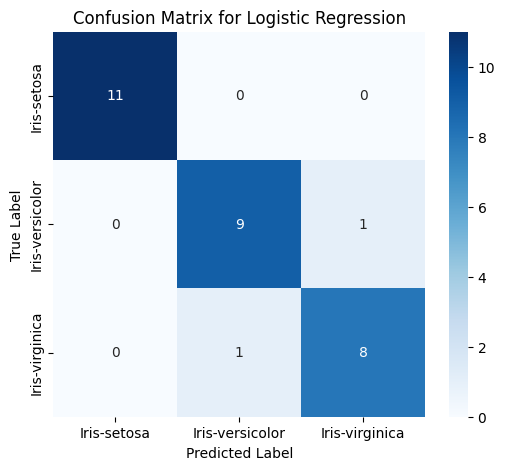

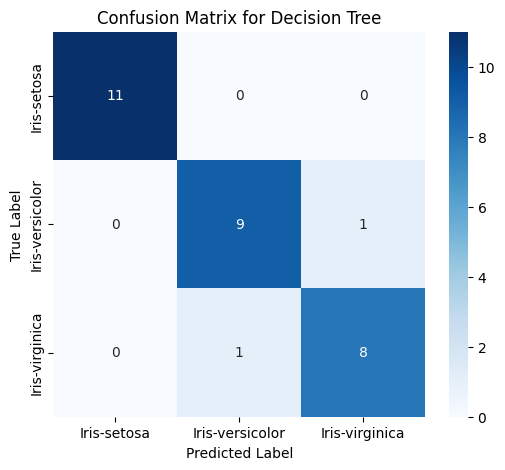

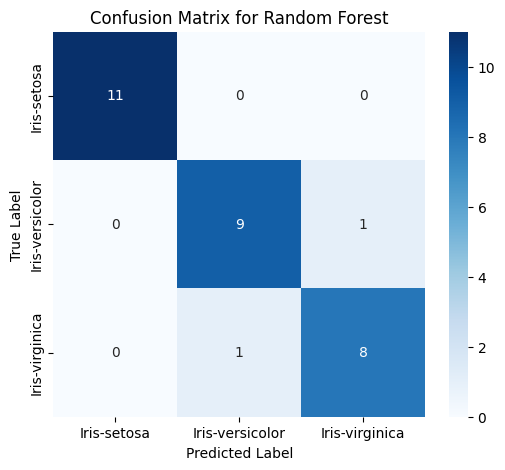

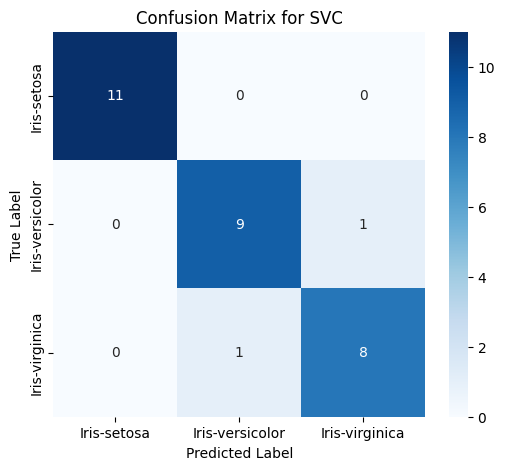

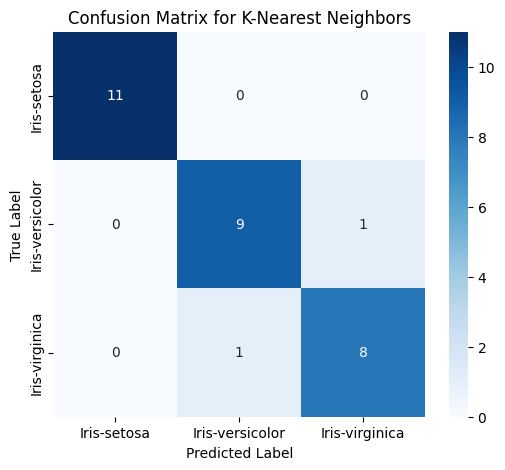

In [12]:
print("\n--- Visualizing Confusion Matrices ---")
for name, metrics in results.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

##Predicting On New Flower Data

In [13]:
# New flower data for prediction (example values)
# Format: SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm
new_flower_data = np.array([
    [5.0, 3.5, 1.3, 0.3],  # Should be Iris-setosa
    [6.0, 2.7, 4.8, 1.8],  # Should be Iris-virginica
    [5.5, 2.3, 4.0, 1.3]   # Should be Iris-versicolor
])

print("\n--- Predicting on New Flower Data ---")

# Scale the new data using the same scaler fitted on the training data
new_flower_data_scaled = scaler.transform(new_flower_data)

# Select a model for prediction (e.g., Logistic Regression)
# You can change this to any model in the 'models' dictionary, e.g., models['Random Forest']
model_for_new_prediction = models['Logistic Regression']

# Make predictions on the scaled new data
new_predictions_encoded = model_for_new_prediction.predict(new_flower_data_scaled)

# Reverse the Label Encoding to get original species names
new_predictions_species = le.inverse_transform(new_predictions_encoded)

# Display the predictions
for i, prediction in enumerate(new_predictions_species):
    print(f"New Flower {i+1} (Features: {new_flower_data[i]}): Predicted Species = {prediction}")


--- Predicting on New Flower Data ---
New Flower 1 (Features: [5.  3.5 1.3 0.3]): Predicted Species = Iris-setosa
New Flower 2 (Features: [6.  2.7 4.8 1.8]): Predicted Species = Iris-virginica
New Flower 3 (Features: [5.5 2.3 4.  1.3]): Predicted Species = Iris-versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


##Save the Trained Model

In [15]:
# Choose the model to save (e.g., Logistic Regression)
model_to_save = models['Logistic Regression']

# Define the filename for the saved model
model_filename = 'logistic_regression_iris_model.joblib'

# Save the model to a file
joblib.dump(model_to_save, model_filename)

print(f"Model saved successfully as '{model_filename}'")

Model saved successfully as 'logistic_regression_iris_model.joblib'
